## Experiment: Impact of Ill-Conditioned Data on Linear Regression
Synthetic data are used to illustrate the behavior of linear regression when applied to ill-conditioned data. 
The dataset consists of a set of input features and corresponding target values, where the features are highly correlated, leading to multicollinearity issues.

In [68]:
import numpy as np

# Configuration
NOISE = 2
SEED = 777
DATASET_SIZE = 100
rng = np.random.default_rng(SEED)

In [69]:
# Function to estimate
def f(x: np.ndarray) -> np.ndarray:
    return x*2 + 2

## Dataset 
The dataset is generated using a linear model with added noise. The input features are created to be highly correlated, which can cause instability in the estimation of regression coefficients. The target variable is generated as a linear combination of the input features plus some random noise.

The dataset is split into training and testing sets to evaluate the performance of the linear regression model.
The training set is 95% of data meanwhile the test set is 5%

A good conditioned dataset is also generated to compare the performance of linear regression on well-conditioned data versus ill-conditioned data.

In [70]:
"""Ill-Conditioned Dataset"""

# Dataset
from core.dataset.dataset import TensorDataset
from core.tensor import Tensor

EPS = 1e-4

x = np.linspace(-5, 5, DATASET_SIZE)
y = x + EPS * rng.standard_normal(DATASET_SIZE)

X = np.stack([x, y]).T
y = f(X)

dataset_tr, dataset_te = TensorDataset(Tensor(X), Tensor(y)).split()
X_tr_ill, y_tr_ill = dataset_tr
X_te_ill, y_te_ill = dataset_te

y_tr_ill += np.random.uniform(-1, 1, y_tr_ill.shape)*NOISE
y_te_ill += np.random.uniform(-1, 1, y_te_ill.shape)*NOISE

print(f'X.shape: {X.shape}, y.shape: {y.shape}')
print(f'X_tr.shape: {X_tr_ill.shape}, y_tr.shape: {y_tr_ill.shape}')
print(f'X_te.shape: {X_te_ill.shape}, y_te.shape: {y_te_ill.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X)}')

X.shape: (100, 2), y.shape: (100, 2)
X_tr.shape: (90, 2), y_tr.shape: (90, 2)
X_te.shape: (10, 2), y_te.shape: (10, 2)
condition number: k(X) = 53974.78736231793


In [71]:
"""Health Dataset"""

# Dataset
from core.dataset.dataset import TensorDataset
from core.tensor import Tensor

x = rng.uniform(-5, 5, DATASET_SIZE)
y = rng.uniform(-5, 5, DATASET_SIZE)

X = np.stack([x, y]).T
y = f(X)

dataset_tr, dataset_te = TensorDataset(Tensor(X), Tensor(y)).split()
X_tr_well, y_tr_well = dataset_tr
X_te_well, y_te_well = dataset_te

y_tr_well += rng.uniform(-1, 1, y_tr_well.shape)*NOISE
y_te_well += rng.uniform(-1, 1, y_te_well.shape)*NOISE

print(f'X.shape: {X.shape}, y.shape: {y.shape}')
print(f'X_tr.shape: {X_tr_well.shape}, y_tr.shape: {y_tr_well.shape}')
print(f'X_te.shape: {X_te_well.shape}, y_te.shape: {y_te_well.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X)}')

X.shape: (100, 2), y.shape: (100, 2)
X_tr.shape: (90, 2), y_tr.shape: (90, 2)
X_te.shape: (10, 2), y_te.shape: (10, 2)
condition number: k(X) = 1.069438902750966


In [72]:
from core.optimizer import SGD
from core.losses import MSELoss
from core.layers import Linear, Sequential

LR = 1e-4

# Linear Regression
model_ill = Sequential(
    Linear(2, 2)
)
model_well = Sequential(
    Linear(2, 2)
)
loss_ill = MSELoss()
loss_well = MSELoss()
optimizer_ill = SGD(model_ill.parameters, LR)
optimizer_well = SGD(model_well.parameters, LR)

In [73]:
"""Training loop configuration"""

LR = 1e-4
EPOCHS = 2500
TEST_STEP = 5

In [74]:
"""Training loop: ill-conditioned dataset"""


assert(EPOCHS % TEST_STEP == 0)
train_losses_ill:list[float] = []
test_losses_ill:list[float] = []

for i in range(EPOCHS):
    pred = model_ill(X_tr_ill)
    train_loss = loss_ill(pred, y_tr_ill)
    train_losses_ill.append(train_loss.data)
    
    if i % TEST_STEP == 0 or i == EPOCHS-1:
        model_ill.eval()
        pred_test = model_ill(X_te_ill)
        test_loss = loss_ill(pred_test, y_te_ill)
        test_losses_ill.append(test_loss.data)
        model_ill.train()

    train_loss.backward()
    optimizer_ill.step()
    optimizer_ill.zero_grad()
    

In [75]:
"""Training loop: well-conditioned dataset"""


assert(EPOCHS % TEST_STEP == 0)
train_losses_well:list[float] = []
test_losses_well:list[float] = []

for i in range(EPOCHS):
    pred = model_well(X_tr_well)
    train_loss = loss_well(pred, y_tr_well)
    train_losses_well.append(train_loss.data)
    
    if i % TEST_STEP == 0 or i == EPOCHS-1:
        model_well.eval()
        pred_test = model_well(X_te_well)
        test_loss = loss_well(pred_test, y_te_well)
        test_losses_well.append(test_loss.data)
        model_well.train()

    train_loss.backward()
    optimizer_well.step()
    optimizer_well.zero_grad()
    

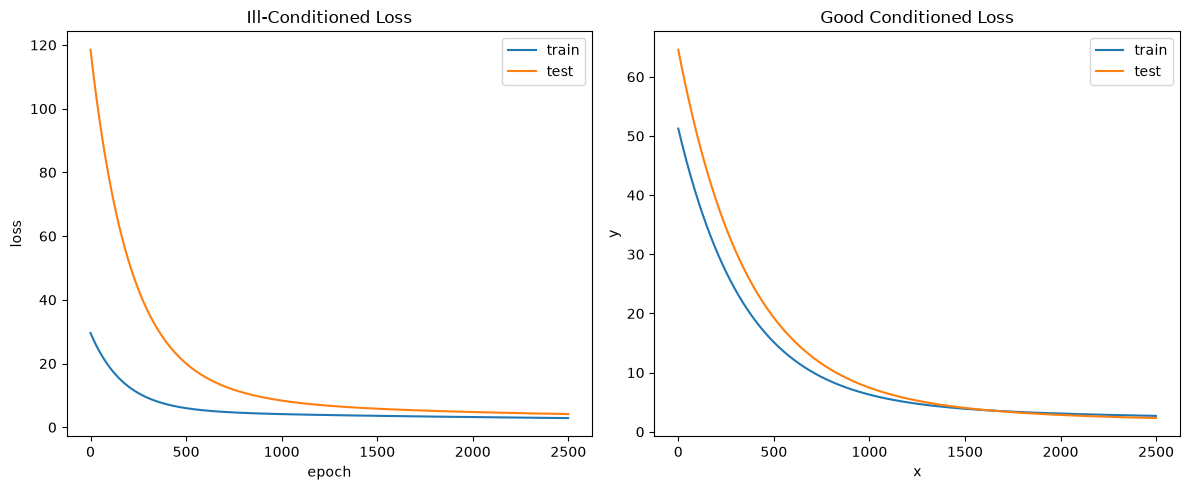

In [76]:
import matplotlib.pyplot as plt

# Loss section

# Plot in one window, divided into sections
fig, (ax_loss_ill, ax_loss_well) = plt.subplots(1, 2, figsize=(12, 5))

# Loss section
ax_loss_ill.plot(list(range(EPOCHS)), train_losses_ill, label="train")
ax_loss_ill.plot(list(range(0, EPOCHS+1, TEST_STEP)), test_losses_ill, label="test")
ax_loss_ill.set_title("Ill-Conditioned Loss")
ax_loss_ill.set_xlabel("epoch")
ax_loss_ill.set_ylabel("loss")
ax_loss_ill.legend()

# Result section (the regression)
ax_loss_well.plot(list(range(EPOCHS)), train_losses_well, label='train')
ax_loss_well.plot(list(range(0, EPOCHS+1, TEST_STEP)), test_losses_well, label='test')
ax_loss_well.set_title("Good Conditioned Loss")
ax_loss_well.set_xlabel("x")
ax_loss_well.set_ylabel("y")
ax_loss_well.legend()

fig.tight_layout()
plt.show()


In [80]:
"""Ill-Conditioned Dataset"""

# Closed form solution
from core.functions import mse


A = np.hstack([X_te_ill.data, np.ones((X_te_ill.shape[0], 1))])
coefs, *_ = np.linalg.lstsq(A, y_te_ill.data, rcond=None)
closed_form = A @ coefs

# Prediction
pred = model_ill(X_te_ill)
W_model, b_model = model_ill.parameters[:]
W_model, b_model = W_model.data, b_model.data.reshape(-1, 1)
params = np.hstack([W_model, b_model]).T

pred_residual = mse(pred.data, closed_form)
weights_residual = mse(params, coefs)

print('RESULTS OF ILL-CONDITIONED DATA\n\n')
print(f'prediction residual: {pred_residual}')
print(f'weights resididual: {weights_residual}\n')
print(f'model params:\n {params}\n')
print(f'closed form coefficent:\n {coefs}')

RESULTS OF ILL-CONDITIONED DATA


prediction residual: 3.005612281940828
weights resididual: 2050472.8385478447

model params:
 [[ 0.78330594  1.0240583 ]
 [-0.28336614  2.244532  ]
 [ 0.711379    0.6926563 ]]

closed form coefficent:
 [[ -930.53137863  2298.32013957]
 [  932.02901172 -2297.46499576]
 [    4.23785525     6.85595467]]


## Considerations

How the reader can see, the predictions residual: `mse(pred, closed_form)` is not very high, instead the weights residual: `mse(w, closed_form_w)` is very high. This is a clear indication of the ill-conditioning of the data, which can lead to unreliable estimates of the regression coefficients.

In [81]:
"""Well-Conditioned Dataset"""

# Closed form solution
from core.functions import mse


A = np.hstack([X_te_well.data, np.ones((X_te_well.shape[0], 1))])
coefs, *_ = np.linalg.lstsq(A, y_te_well.data, rcond=None)
closed_form = A @ coefs

# Prediction
pred = model_well(X_te_well)
W_model, b_model = model_well.parameters[:]
W_model, b_model = W_model.data, b_model.data.reshape(-1, 1)
params = np.hstack([W_model, b_model]).T

pred_residual = mse(pred.data, closed_form)
weights_residual = mse(params, coefs)

print('RESULTS OF WELL-CONDITIONED DATA\n\n')
print(f'prediction residual: {pred_residual}')
print(f'weights resididual: {weights_residual}\n')
print(f'model params:\n {params}\n')
print(f'closed form coefficent:\n {coefs}')

RESULTS OF WELL-CONDITIONED DATA


prediction residual: 1.5678727714102845
weights resididual: 0.41107187219985586

model params:
 [[ 1.868562   -0.00416512]
 [ 0.00441814  1.7940737 ]
 [ 0.74080527  0.630273  ]]

closed form coefficent:
 [[ 2.22701483  0.03570634]
 [-0.21560467  1.98612898]
 [ 1.95526082  1.51126987]]


# Conclusion

In this experiment, we have demonstrated the impact of ill-conditioned data on linear regression. 

The high condition number of the input features leads to instability in the estimation of regression coefficients, resulting in unreliable predictions. It is important to be aware of the condition number of the data when applying linear regression, as it can significantly affect the performance and reliability of the model.